In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

from plots import EventPlot, RegionalStormTracks

from shapely.geometry import LineString # shapely.geometry's LineStrings help create a single geometry for each storm track
from shapely.geometry import box # 

import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# loading the dataset 
url = "https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/csv/ibtracs.ALL.list.v04r01.csv"
df = pd.read_csv(url, skiprows=[1], low_memory=False)

In [3]:
df.head(2)

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,...,BOM_GUST_PER,REUNION_GUST,REUNION_GUST_PER,USA_SEAHGT,USA_SEARAD_NE,USA_SEARAD_SE,USA_SEARAD_SW,USA_SEARAD_NW,STORM_SPEED,STORM_DIR
0,1842298N11080,1842,1,NI,BB,UNNAMED,1842-10-25 03:00:00,NR,10.9,80.3,...,,,,,,,,,9,265
1,1842298N11080,1842,1,NI,BB,UNNAMED,1842-10-25 06:00:00,NR,10.9,79.8,...,,,,,,,,,9,265


In [4]:
print(list(df.columns))

['SID', 'SEASON', 'NUMBER', 'BASIN', 'SUBBASIN', 'NAME', 'ISO_TIME', 'NATURE', 'LAT', 'LON', 'WMO_WIND', 'WMO_PRES', 'WMO_AGENCY', 'TRACK_TYPE', 'DIST2LAND', 'LANDFALL', 'IFLAG', 'USA_AGENCY', 'USA_ATCF_ID', 'USA_LAT', 'USA_LON', 'USA_RECORD', 'USA_STATUS', 'USA_WIND', 'USA_PRES', 'USA_SSHS', 'USA_R34_NE', 'USA_R34_SE', 'USA_R34_SW', 'USA_R34_NW', 'USA_R50_NE', 'USA_R50_SE', 'USA_R50_SW', 'USA_R50_NW', 'USA_R64_NE', 'USA_R64_SE', 'USA_R64_SW', 'USA_R64_NW', 'USA_POCI', 'USA_ROCI', 'USA_RMW', 'USA_EYE', 'TOKYO_LAT', 'TOKYO_LON', 'TOKYO_GRADE', 'TOKYO_WIND', 'TOKYO_PRES', 'TOKYO_R50_DIR', 'TOKYO_R50_LONG', 'TOKYO_R50_SHORT', 'TOKYO_R30_DIR', 'TOKYO_R30_LONG', 'TOKYO_R30_SHORT', 'TOKYO_LAND', 'CMA_LAT', 'CMA_LON', 'CMA_CAT', 'CMA_WIND', 'CMA_PRES', 'HKO_LAT', 'HKO_LON', 'HKO_CAT', 'HKO_WIND', 'HKO_PRES', 'KMA_LAT', 'KMA_LON', 'KMA_CAT', 'KMA_WIND', 'KMA_PRES', 'KMA_R50_DIR', 'KMA_R50_LONG', 'KMA_R50_SHORT', 'KMA_R30_DIR', 'KMA_R30_LONG', 'KMA_R30_SHORT', 'NEWDELHI_LAT', 'NEWDELHI_LON', 'N

In [5]:
numeric_conversion_cols = ['LAT', 'LON', 'USA_WIND', 'SEASON']

# convert key columns to numeric (empty strings to nans)
for col in numeric_conversion_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

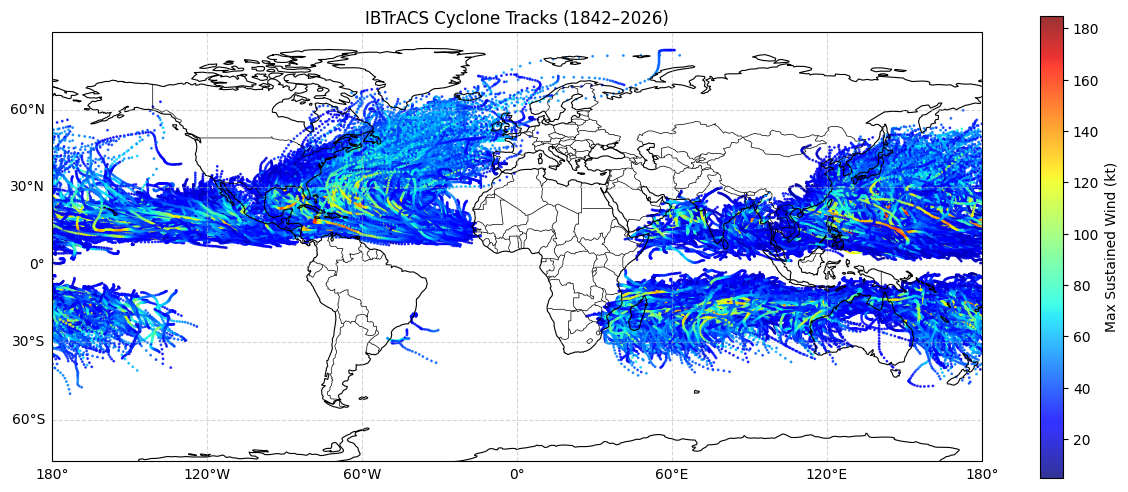

In [6]:
fig = plt.figure(figsize=(15, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Scatter points
sc = ax.scatter(df['LON'], df['LAT'], c=df['USA_WIND'], cmap='jet', s=1, alpha=0.8, transform=ccrs.PlateCarree())

# coastlines and country borders
ax.coastlines(resolution='110m', linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# gridlines lat lon
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False; gl.right_labels = False

plt.colorbar(sc, ax=ax, label='Max Sustained Wind (kt)')
plt.title('IBTrACS Cyclone Tracks (1842–2026)')
plt.show()

### Historical Events

### Tracking a few events in different basins 
Storms like Vince in Spain, Milton in United States, Amphan in India and Ragasa in Hong Kong.

a search using storm NAME is a little inefficient, so let's do it based on Event IDs or SID instead. This will allow us to filter the dataframe more efficiently and avoid potential issues with duplicate storm names across different years or basins.

In [7]:
# for example VINCE in Spain. 
VINCE = df[df['NAME'].str.upper() == 'VINCE'].copy()
print(VINCE.groupby('SID').size())

SID
2005281N33339     27
2011009S15113     59
2025031S15106    107
dtype: int64


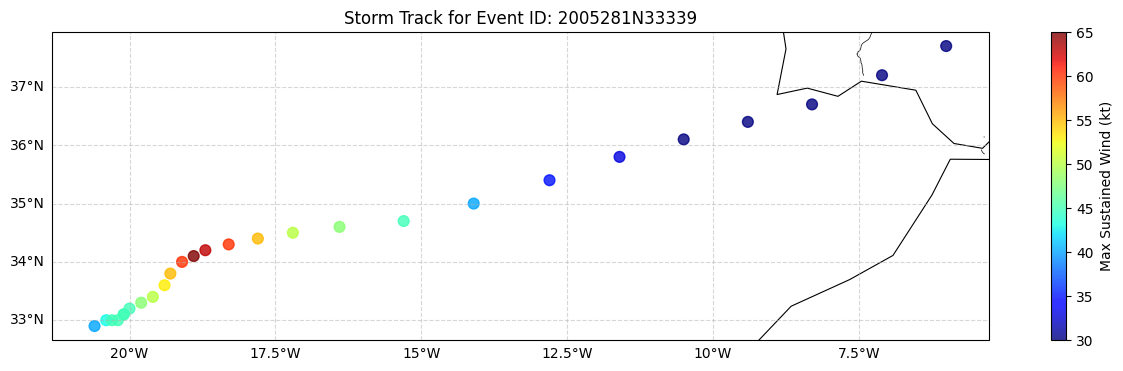

In [8]:
EventPlot(df, '2005281N33339')

In [9]:
storms = ['VINCE', 'AMPHAN', 'MILTON', 'RAGASA']

# search for SIDs for the above storms. 
for name in storms:
    sids = df[df['NAME'].str.upper() == name.upper()]['SID'].dropna().unique()
    print(name, sids)

VINCE ['2005281N33339' '2011009S15113' '2025031S15106']
AMPHAN ['2020136N10088']
MILTON ['2024279N21265']
RAGASA ['2025260N13138']


In [10]:
# Final events to plot
eventIDs = ['2005281N33339', '2020136N10088', '2024279N21265', '2025260N13138']

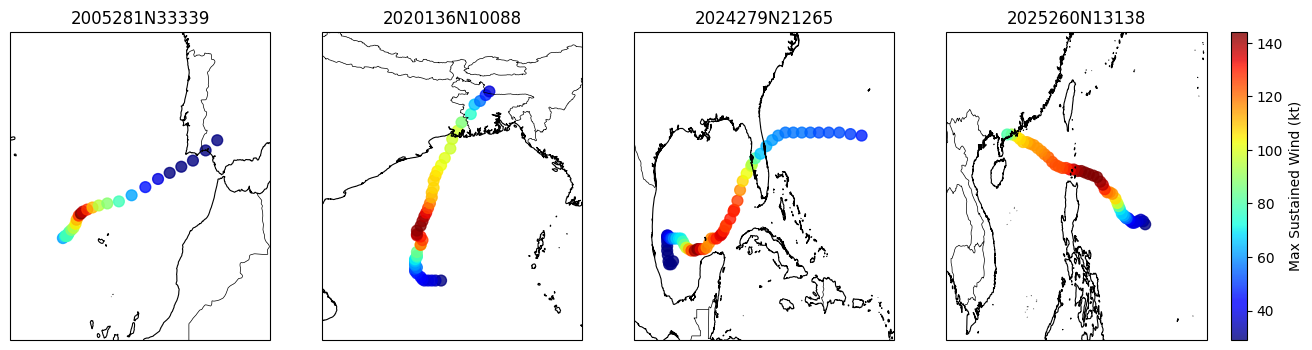

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), subplot_kw={'projection': ccrs.PlateCarree()})

for ax, name in zip(axes, eventIDs):

    storm = df[df['SID'] == name]

    sc = ax.scatter(storm['LON'], storm['LAT'], c=storm['USA_WIND'], cmap='jet', s=60, alpha=0.8, transform=ccrs.PlateCarree())

    # Coastlines
    ax.coastlines(resolution='10m', linewidth=0.8) ; ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # Zoom to storm extent with padding
    if len(storm) > 0:
        pad = 5
        ax.set_extent([
            storm['LON'].min() - pad,
            storm['LON'].max() + pad,
            storm['LAT'].min() - pad,
            storm['LAT'].max() + pad
        ])

    # Keep equal dimensions across subplots
    ax.set_aspect('auto')

    ax.set_title(name)

# Vertical colorbar on the far right of all axes
cbar = fig.colorbar(sc, ax=axes, orientation='vertical', fraction=0.015, pad=0.02)
cbar.set_label('Max Sustained Wind (kt)')

plt.show()

### Regional Analysis: Focus on Asia 

In [12]:
# high-res 1:10m administrative countries layer
url_10m = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_admin_0_countries.geojson"
world = gpd.read_file(url_10m)

In [13]:
# Standardize continent column naming (10m uses CONTINENT or CONTINENT_)
continents = world.dissolve(by='CONTINENT').reset_index() # .dissolve(by="CONTINET") works because 
continents = continents[['CONTINENT', 'geometry']]

In [14]:
print(continents)

                 CONTINENT                                           geometry
0                   Africa  MULTIPOLYGON (((-16.05565 11.04946, -16.07616 ...
1               Antarctica  MULTIPOLYGON (((-169.81611 -83.18027, -169.828...
2                     Asia  MULTIPOLYGON (((53.26807 12.12883, 53.28688 12...
3                   Europe  MULTIPOLYGON (((-54.26379 2.14819, -54.31402 2...
4            North America  MULTIPOLYGON (((-160.01244 -0.38209, -160.0247...
5                  Oceania  MULTIPOLYGON (((-176.22118 -44.32399, -176.227...
6  Seven seas (open ocean)  MULTIPOLYGON (((-27.14818 -59.46299, -27.15294...
7            South America  MULTIPOLYGON (((-75.01618 -51.41351, -75.03132...


In [15]:
# Filter to get Asia
Asia = continents[continents['CONTINENT'] == 'Asia']

<Axes: >

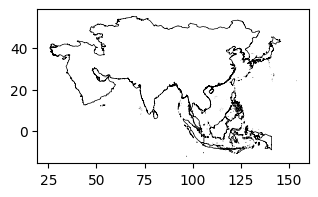

In [16]:
Asia.plot(figsize=(5, 2), color='white', edgecolor='black', linewidth=0.5)

In [17]:
# Clean coordinates for plotting (convert to numeric and drop rows with NaN)
df['LAT'] = pd.to_numeric(df['LAT'], errors='coerce')
df['LON'] = pd.to_numeric(df['LON'], errors='coerce')
df = df.dropna(subset=['LAT', 'LON'])

In [18]:
# shapely.geometry's LineStrings help create a single geometry for each storm track
# Build one LineString per storm 

df_sorted = df.sort_values(['SID', 'ISO_TIME'])

tracks = []
for sid, grp in df_sorted.groupby('SID'):
    if len(grp) >= 2:
        tracks.append({'SID': sid, 'NAME': grp['NAME'].iloc[0],
                        'geometry': LineString(zip(grp['LON'], grp['LAT']))})

tracks_gdf = gpd.GeoDataFrame(tracks, crs="EPSG:4326")

In [19]:
AsiaUnion = Asia.geometry.union_all()
tracks_through_area = tracks_gdf[tracks_gdf.intersects(AsiaUnion)]

print(f"Number of storms whose track passed through the area: {len(tracks_through_area)}")
tracks_through_area[['SID', 'NAME']]

Number of storms whose track passed through the area: 3800


,SID,NAME
0,1842298N11080,UNNAMED
69,1854303N14072,UNNAMED
425,1870101S07108,UNNAMED
584,1877135N10083,UNNAMED
585,1877192N21090,UNNAMED
...,...,...
13491,2026219N29161,CHAN-HOM
13497,2026231N08155,SAUDEL
13500,2026233N20108,NARRA
13510,2026243N20110,SAUDEL


In [37]:
prob_any_storm_hits_area = len(tracks_through_area) / tracks_gdf['SID'].nunique()
print(f"Historical probability of a storm's track passing through this area: {prob_any_storm_hits_area:.2%}")

Historical probability of a storm's track passing through this area: 28.12%


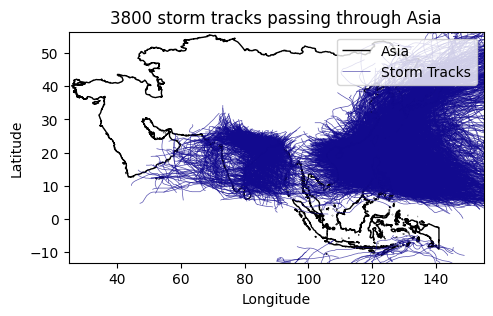

In [20]:
RegionalStormTracks(Asia, tracks_through_area, 'Asia')

In [23]:
# Grid over the area, with a bit of buffer so you see context around it too
minx, miny, maxx, maxy = Asia.total_bounds
buffer = 0.5
minx, miny, maxx, maxy = minx - buffer, miny - buffer, maxx + buffer, maxy + buffer

n_cells = 40  # resolution - increase for finer detail
x_edges = np.linspace(minx, maxx, n_cells + 1)
y_edges = np.linspace(miny, maxy, n_cells + 1)

grid_cells = [box(x_edges[i], y_edges[j], x_edges[i+1], y_edges[j+1])
              for i in range(n_cells) for j in range(n_cells)]
grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs="EPSG:4326")

In [25]:
# Count how many distinct storm tracks intersect each cell
grid['track_count'] = grid.geometry.apply(lambda cell: tracks_gdf.intersects(cell).sum())

# Probability = fraction of all storms in the record that touched that cell
total_storms = tracks_gdf['SID'].nunique()
grid['probability'] = grid['track_count'] / total_storms

In [30]:
grid["probability"].describe()

count    1600.000000
mean        0.003749
std         0.006984
min         0.000000
25%         0.000000
50%         0.000148
75%         0.004070
max         0.040847
Name: probability, dtype: float64

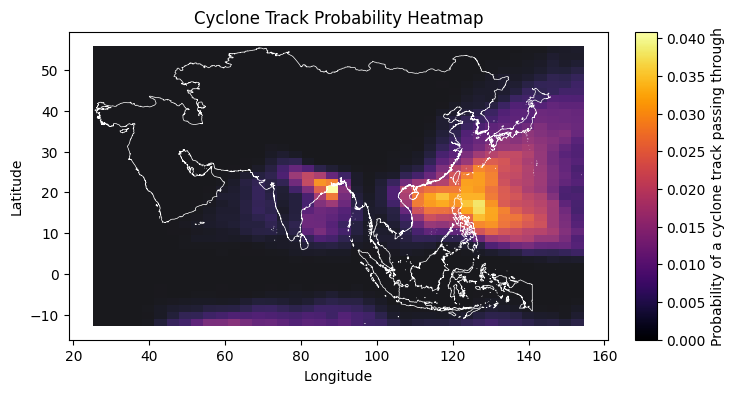

In [35]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(7, 4))

grid.plot(column='probability', ax=ax, cmap='inferno', legend=False, alpha=0.9)

Asia.boundary.plot(ax=ax, color='white', linewidth=0.5)

# Colorbar with the same height as the map
norm = Normalize(vmin=grid['probability'].min(), vmax=grid['probability'].max())
sm = ScalarMappable(norm=norm, cmap='inferno')
sm.set_array([])

cax = inset_axes(ax, width='4%', height='100%', loc='lower left', bbox_to_anchor=(1.05, 0, 1, 1), bbox_transform=ax.transAxes, borderpad=0)

fig.colorbar(sm, cax=cax, label='Probability of a cyclone track passing through')

ax.set_title('Cyclone Track Probability Heatmap')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()